### Selecionando origens

Resultado esperado:
- Origens selecionadas a partir de um poligono

In [1]:
# Instala dependencias
%pip install geopandas pyogrio shapely neatnet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# Bibliotecas 
import sys
from pathlib import Path
import geopandas as gpd
import pyogrio as ogr
import shapely as shp
import neatnet
import pathlib
import matplotlib.pyplot as plt
import osmnx as ox
import json

import networkx as nx

%matplotlib inline


In [24]:
# adiciona a raiz do projeto ao Python
sys.path.append(str(Path.cwd().parent))

# Importa metodos
import src.converters as converter

In [2]:
# Carrega o arquivo de json de configuração
#   open -> inputs: arquivo, modo de abertura, codificação
with open("../config/config.json", "r", encoding="utf-8") as config_file:
    config = json.load(config_file)

# Configurações
study_area = config["study_area"]
crs = study_area["crs"]

cidade = study_area["place"]
network_type = study_area["network_type"]

Carrega rede

In [77]:
# Rede Bom Fim
graph = ox.load_graphml("../data/graph/rede-bomFim.graphml")

# Rede Porto Alegre
graph_poa = ox.load_graphml("../data/graph/rede-poa.graphml")


Carrega origens

In [4]:
# Carrega origens
origens = gpd.read_file(
    "../data/o-d/origens_porto_alegre.gpkg",
    layer="origens"
)

In [5]:
# Verificar se a rede é formada por mais de um componente
componentes = list(nx.weakly_connected_components(graph))

print("Número de componentes:", len(componentes))


Número de componentes: 1


Se nmr de componentes > 1

In [6]:
# Gera os componentes fracamente conectados
componentes = sorted(
    nx.weakly_connected_components(graph),
    key=len,
    reverse=True
)

# Quantos nós tem cada componente
for i, componente in enumerate(componentes):
    print(f"Componente {i}: {len(componente)} nós")

Componente 0: 55 nós


-------------------------
**Exemplo de resultado**

Componente 0: 125430 nós

Componente 1: 18 nós

Componente 2: 7 nós

Componente 3: 3 nós

*Interpretação: Isso já sugere que o componente 0 é a rede principal e os outros são pequenos trechos isolados*

-------------------------

Baixa bairros, converte e salva

In [ ]:
# Carrega arquivo com os bairros
bairros_shp = gpd.read_file("../data/bairros/Bairros_LC12112_16.shp")

# Converte o sistema de coordenadas para EPSG:31982
bairros_31982_shp = bairros_shp.to_crs("EPSG:31982")

# Salva
bairros_31982_shp.to_file(
    "../data/bairros/Bairros_LC12112_16.gpkg",
    driver="GPKG"
)

Carrega bairros

In [ ]:
# Carrega bairros
bairros = gpd.read_file("../data/bairros/Bairros_LC12112_16.gpkg")

In [56]:
# Verifica o sistema de coordenadas
print(bairros.crs.to_epsg())
print(origens.crs.to_epsg())

print("CRS bairros:", bairros.crs)
print("CRS origens:", origens.crs)

print("\nBounds bairros:")
print(bairros.total_bounds)

print("\nBounds origens:")
print(origens.total_bounds)

31982
31982
CRS bairros: EPSG:31982
CRS origens: EPSG:31982

Bounds bairros:
[ 471074.37929226 6651359.12984069  498900.68000516 6688854.88798952]

Bounds origens:
[ 473856.72696696 6652239.14044548  498744.37742289 6686325.7469253 ]


Seleciona bairro

In [59]:
bomfim = bairros[bairros["NOME"] == "BOM FIM"]

C:\Users\Simone\AppData\Local\Temp\ipykernel_43660\560427498.py:26: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


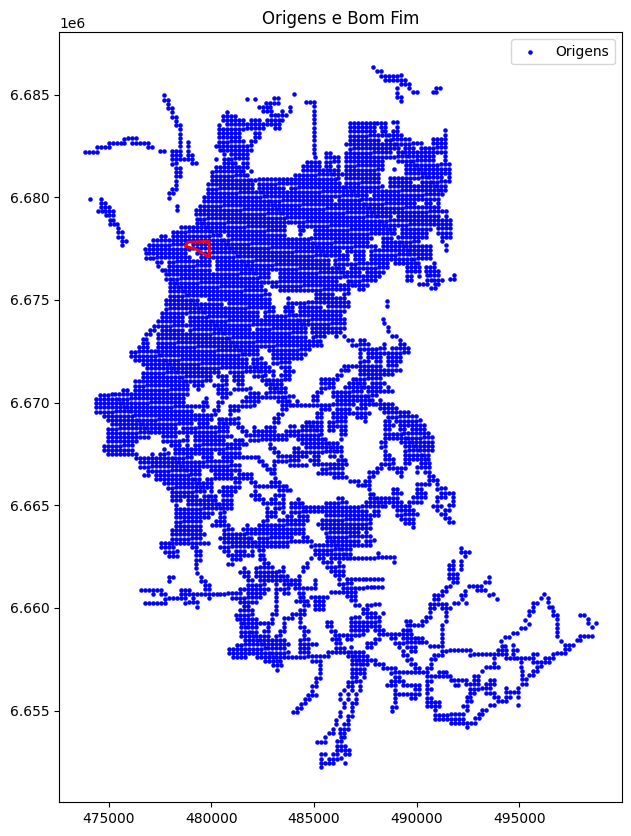

In [61]:
# Plota origens e bairro Bom Fim
fig, ax = plt.subplots(figsize=(10, 10))

# Todas as origens
origens.plot(
    ax=ax,
    color="blue",
    markersize=5,
    label="Origens"
)

# Bom Fim transformado para o mesmo CRS das origens
bomfim = bairros[
    bairros["NOME"] == "BOM FIM"
]

bomfim.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    label="Bom Fim"
)

ax.set_title("Origens e Bom Fim")
ax.legend()

plt.show()

In [ ]:
# REVER
# Veirifica dados do Bom Fim
print("Dados bairro:")
print(bomfim.crs)
print(bomfim.geometry.area)

# Cria polígono do Bom Fim
bomfim_geometry = bomfim.geometry.iloc[0]
print("Dados origens:")
print(origens.crs)
print(origens.geometry.head())

# Filtra origens localizadas dentro do bairro Bom Fim
origens_bomfim = origens[origens.geometry.within(bomfim_geometry)]
print(f"Origens dentro do bairro Bom Fim:\n {origens_bomfim}")

# Salva as origens dentro do bairro Bom Fim
origens_bomfim.to_file(
    "../data/o-d/origens_bomfim.gpkg",
    layer="origens_bomfim",
    driver="GPKG"
)

Dados bairro:
EPSG:31982
51    494977.108395
dtype: float64
Dados origens:
EPSG:31982
0    POINT (474386.204 6669552.438)
1     POINT (474578.68 6669554.914)
2     POINT (474383.84 6669760.062)
3    POINT (474576.318 6669762.539)
4    POINT (474381.475 6669967.684)
Name: geometry, dtype: geometry
Origens dentro do bairro Bom Fim:
       origin_id          ID_UNICO       nome_1KM       nome_5KM  \
1104     2835.0  200ME52788N80052  1KME5278N8005  5KME5275N8005   
1107     2839.0  200ME52786N80054  1KME5278N8005  5KME5275N8005   
1108     2840.0  200ME52788N80054  1KME5278N8005  5KME5275N8005   
1435     3437.0  200ME52792N80050  1KME5279N8004  5KME5275N8000   
1436     3438.0  200ME52794N80050  1KME5279N8004  5KME5275N8000   
1439     3441.0  200ME52790N80052  1KME5279N8005  5KME5275N8005   
1440     3442.0  200ME52792N80052  1KME5279N8005  5KME5275N8005   
1441     3443.0  200ME52794N80052  1KME5279N8005  5KME5275N8005   
1444     3446.0  200ME52790N80054  1KME5279N8005  5KME5275N8005 

In [69]:
print("Bounds bairros:")
print(bairros.total_bounds)

print("Bounds origens:")
print(origens.total_bounds)

print("Área real do Bom Fim:")
print(bomfim.geometry.area)

print(origens.geometry.head())
print(bairros.geometry.head())

Bounds bairros:
[ 471074.37929226 6651359.12984069  498900.68000516 6688854.88798952]
Bounds origens:
[ 473856.72696696 6652239.14044548  498744.37742289 6686325.7469253 ]
Área real do Bom Fim:
51    494977.108395
dtype: float64
0    POINT (474386.204 6669552.438)
1     POINT (474578.68 6669554.914)
2     POINT (474383.84 6669760.062)
3    POINT (474576.318 6669762.539)
4    POINT (474381.475 6669967.684)
Name: geometry, dtype: geometry
0    POLYGON ((487600.113 6679921.089, 487640.855 6...
1    POLYGON ((482826.114 6679028.032, 482816.487 6...
2    POLYGON ((485888.362 6678177.003, 485812.175 6...
3    POLYGON ((490479.74 6680667.875, 490481.082 66...
4    POLYGON ((489407.874 6680971.51, 489404.267 66...
Name: geometry, dtype: geometry


In [71]:
print(len(origens))
print(len(origens_bomfim))

6189
11


In [72]:

# Cria um dicionário que mapeia cada nó para o índice do componente ao qual ele pertence
node_to_component = {}

for i, componente in enumerate(componentes):
    for node in componente:
        node_to_component[node] = i

origens["componente"] = origens["node"].map(node_to_component)

print(origens[["origin_id", "node", "componente"]])
origens["componente"].unique()

      origin_id        node  componente
0         235.0  2248442166         NaN
1         236.0   296249745         NaN
2         237.0  2248442166         NaN
3         238.0   508060554         NaN
4         239.0   583532859         NaN
...         ...         ...         ...
6184    12866.0  8658562772         NaN
6185    12869.0  8658562772         NaN
6186    12871.0  8658562772         NaN
6187    12872.0  8658562772         NaN
6188    12875.0  1011917815         NaN

[6189 rows x 3 columns]


array([nan,  0.])

In [73]:
print(type(graph))
node = origens.iloc[0]["node"]

print(node)
print(node in graph.nodes)
origens["node"].isin(graph.nodes).value_counts()

<class 'networkx.classes.multidigraph.MultiDiGraph'>
2248442166
False


node
False    6174
True       15
Name: count, dtype: int64

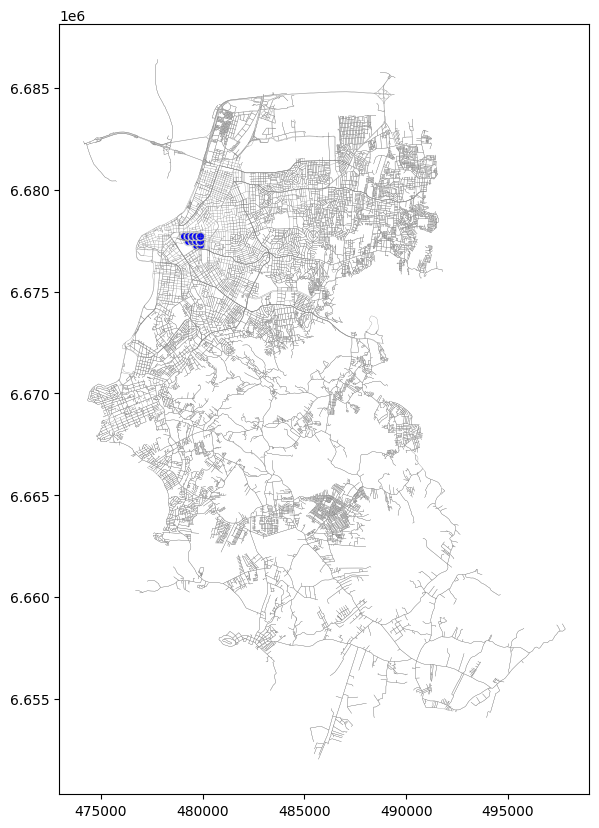

In [82]:
# Converte as arestas da rede para GeoDataFrame
edges_poa = ox.graph_to_gdfs(
    graph_poa,
    nodes=False,
    edges=True
)

# Cria figura
figure, axis = plt.subplots(figsize=(10, 10))

# Plota origens do Bom Fim
origens_bomfim.plot(
    ax=axis,
    facecolor="blue",
    edgecolor="lightgray"
)

# Plota a rede de Porto Alegre
edges_poa.plot(
    ax=axis,
    color="grey",
    linewidth=0.2
)

plt.show()

AttributeError: 'MultiDiGraph' object has no attribute 'plot'

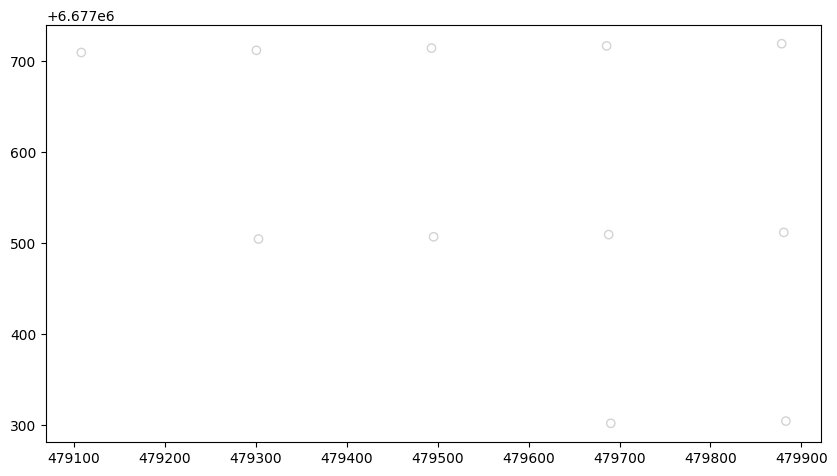

In [78]:
figure, axis = plt.subplots(figsize=(10,10))

origens_bomfim.plot(ax=axis, facecolor="none", edgecolor="lightgray")
graph_poa.plot(ax=axis, color="red", markersize=2)

plt.show()